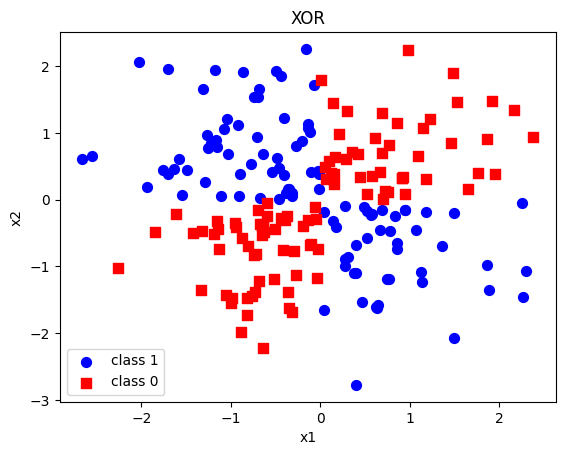

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = np.random.randn(200, 2) # N(0,1)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
y_xor = np.where(y, 1, 0)
plt.scatter(X[y_xor == 1, 0], X[y_xor == 1, 1],
            c='b', marker='o', label='class 1', s=50)
plt.scatter(X[y_xor == 0, 0], X[y_xor == 0, 1],
            c='r', marker='s', label='class 0', s=50)
plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR")
plt.show()


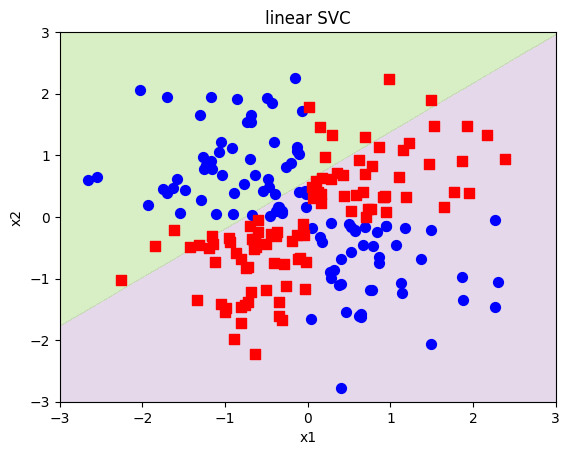

In [2]:
def plot_xor(X, y, model, title, xmin=-3, xmax=3, ymin=-3, ymax=3):
    XX, YY = np.meshgrid(np.arange(xmin, xmax, (xmax-xmin)/1000),
                         np.arange(ymin, ymax, (ymax-ymin)/1000))
    ZZ = np.reshape(model.predict(
        np.array([XX.ravel(), YY.ravel()]).T), XX.shape)
    plt.contourf(XX, YY, ZZ, cmap=plt.cm.Paired_r, alpha=0.5)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='b',
                marker='o', label='class 1', s=50)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='r',
                marker='s', label='class 0', s=50)
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")

from sklearn.svm import SVC

svc = SVC(kernel="linear").fit(X, y)
plot_xor(X, y, svc, "linear SVC")
plt.show()

In [ ]:
X.shape, y.shape

((200, 2), (200,))

In [3]:
X_kernel = np.vstack([X[:, 0]**2, np.sqrt(2)*X[:, 0]*X[:, 1], X[:, 1]**2]).T
X_kernel.shape

(200, 3)

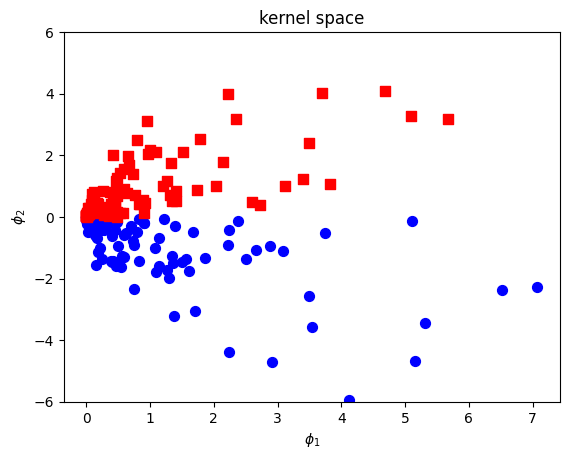

In [4]:
plt.scatter(X_kernel[y == 1, 0], X_kernel[y == 1, 1], c="b", marker='o', s=50)
plt.scatter(X_kernel[y == 0, 0], X_kernel[y == 0, 1], c="r", marker='s', s=50)
plt.ylim(-6, 6)
plt.title("kernel space")
plt.xlabel(r"$\phi_1$")
plt.ylabel(r"$\phi_2$")
plt.show()

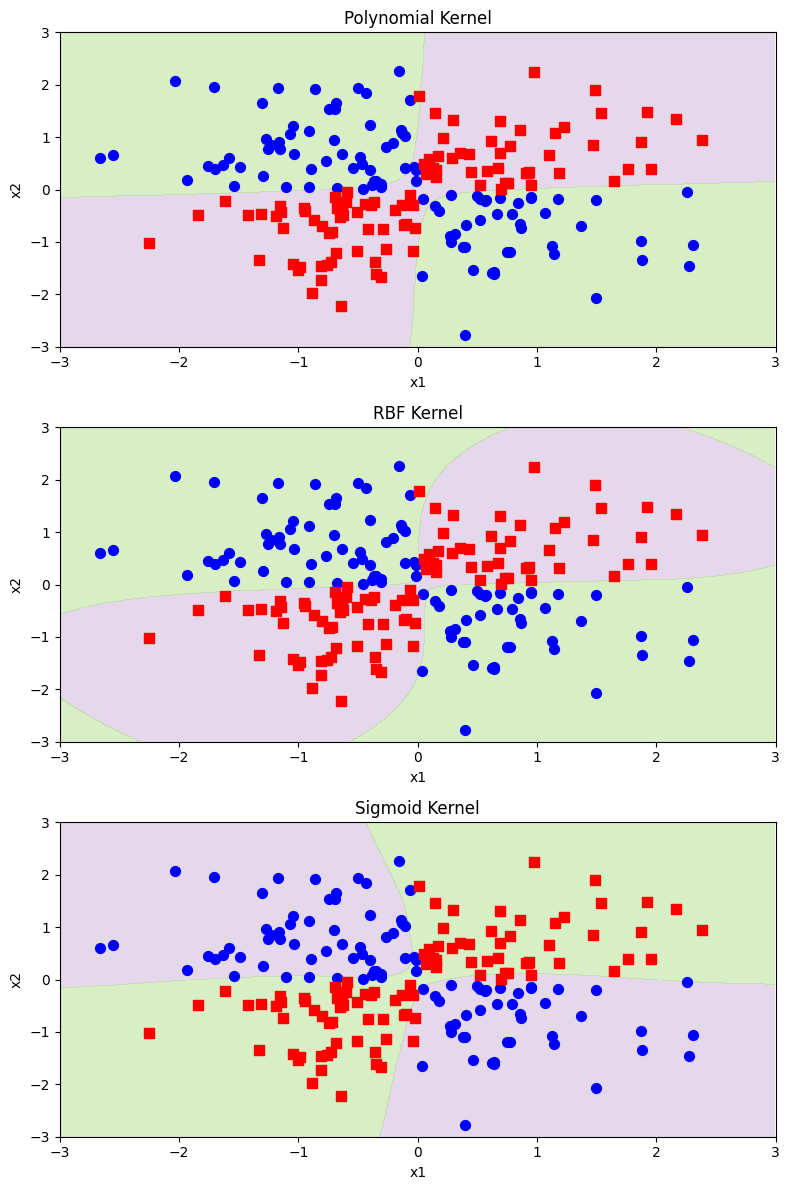

In [5]:
polysvc = SVC(kernel="poly", degree=2, gamma=1, coef0=0).fit(X, y)
rbfsvc = SVC(kernel="rbf").fit(X, y)
sigmoidsvc = SVC(kernel="sigmoid", gamma=2, coef0=2).fit(X, y)

plt.figure(figsize=(8, 12))
plt.subplot(311)
plot_xor(X, y, polysvc, "Polynomial Kernel")
plt.subplot(312)
plot_xor(X, y, rbfsvc, "RBF Kernel")
plt.subplot(313)
plot_xor(X, y, sigmoidsvc, "Sigmoid Kernel")
plt.tight_layout()
plt.show()